# Project

Author:
Filipe Carvalho

## Proposal

Based  on  the  previous  observations  of  the  Take-Two Interactive stock  value,  the  aim  of  this 
project is to analysis, visualize, perform a diagnostic analysis, and forecast values 
for this stock. The library implemented to extract market data is called yfinance. 
This library offers a reliable, threaded, and Pythonic way to download historical 
market data from Yahoo! finance. For my project, I will be focused on the Take-Two Interactive 
stock  (ticker  symbol  TTWO).  Another  subsequently  objective  of  this  project  is 
towards  getting  knowledge  about  the  market  and  stocks,  as  I  am  interested  in 
getting experience about this to invest in the market in a near future. 

# Library Imports

In [1]:
import warnings

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import lag_plot
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore")

# Data Description and Sourcing

Source: Yahoo! finance (imported using yfinance)

| Columns      | Description                                                                                         | Type    |
| ------------ | --------------------------------------------------------------------------------------------------- | ------- |
| Date         | Format: dd/mm/YY <br> Frequency: Daily                                                              | Date    |
| Open         | Stock value when market opens                                                                       | Decimal |
| High         | Highest value recorded in a day                                                                     | Decimal |
| Low          | Lowest value recorded in a day                                                                      | Decimal |
| Close        | Stock value when market closes                                                                      | Decimal |
| Volume       | Number of shares traded in one day                                                                  | Integer |
| Dividends    | When company gives dividends <br> TTWO does not pay dividends, all values are zero, will be dropped | Boolean |
| Stock Splits | Stock splits information <br> All values are zero, will be dropped                                  | Boolean |


## Close price context

This project will focus on the close prices since it reflects most of the information accumulated during the trading session and is conventionally treated as a representative daily value. ``Close`` price helps reduce the impact of certain short-term noise such as overnight news and pre-market sentiment which are typically reflected by the ``Open`` price and may not reflect the overall trading session dynamics, furthermore ``High`` and ``Low`` often reflect intraday extremes rather than typical price levels. 

Hence, ``Close`` is the ideal series for analysis in this context.


In [2]:
ttwo = yf.Ticker("TTWO")

df = ttwo.history(start="2024-04-24", end="2026-04-24") # At least 2 years of data according to the requirements

df.index = pd.to_datetime(df.index).tz_localize(None)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 501 entries, 2024-04-24 to 2026-04-23
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          501 non-null    float64
 1   High          501 non-null    float64
 2   Low           501 non-null    float64
 3   Close         501 non-null    float64
 4   Volume        501 non-null    int64  
 5   Dividends     501 non-null    float64
 6   Stock Splits  501 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 31.3 KB


## Data Cleaning

### Column selection

As mentioned in the table above, Dividend and stock split columns are constant (all zeros) for this dataset and do not contribute information to variability or modeling.

In [3]:
df = df.drop(columns=["Dividends", "Stock Splits", "Open", "High", "Low", "Volume"])

### Date-time formatting 

Data is already in the correct date-time format.

### Missing values

There are no missing values. (Can be seen from the .info() command)

### Outliers Identification

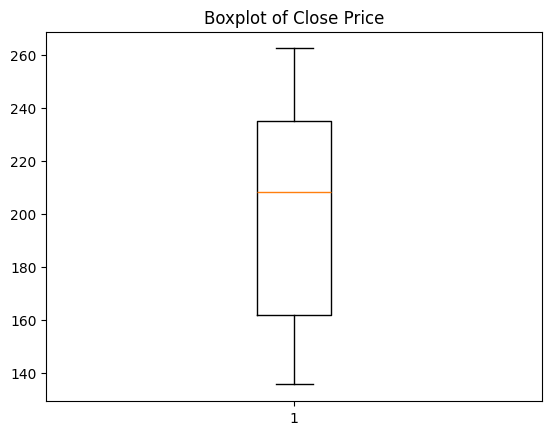

In [4]:
plt.figure()
plt.boxplot(df["Close"])
plt.title("Boxplot of Close Price")
plt.show()

No outliers identified.

# Exploratory Data Analysis

## Describe the data

In [5]:
print(df.describe())

            Close
count  501.000000
mean   202.568962
std     36.529584
min    135.669998
25%    161.789993
50%    208.130005
75%    234.899994
max    262.290009


The stock’s average closing price is 202.57.

It indicates that generally the stock trades in the low 200s over the selected two‑year period. The standard deviation of 36.53 indicates a higher level of variability around the mean. Quartiles (161.79, 208.13, 234.90) show that most prices are concentrated within a relatively wide price interval. The median is slightly above the mean, which hints at mild left skew.

## Plot the time series

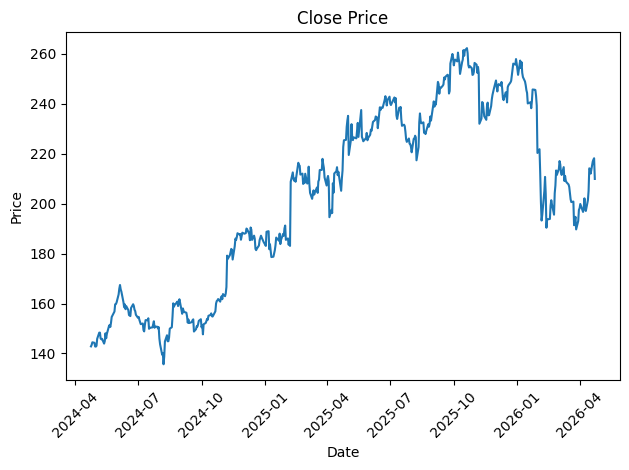

In [6]:
plt.figure()
plt.plot(df["Close"])
plt.title("Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The series shows an uptrend from mid 2024 to mid 2025 with the pricing rising from around 140 low to 260 high, this phase is relatively smooth with some moderate lows and highs, in general its a steady uptrend with some periods of consolidation (pullbacks followed by continued growth).

Some uncertainty can be seen at January 2026 where the price drops from a 250 peak to 235 which recovers briefly, however after that recovery there is an abrupt price drop to 190 during February, which points to a major event at the company or a significant change in the market conditions or in the relevant sector.

Clearly, the graph shows systematic mean change. The span of the values seems mostly constant averaging around 20 dollars (visually), except during September 2025 to November 2025 where the span increases to around 40 dollars. This suggests higher volatility during that period. Hence, the series is not stationary.

## Series Distribution

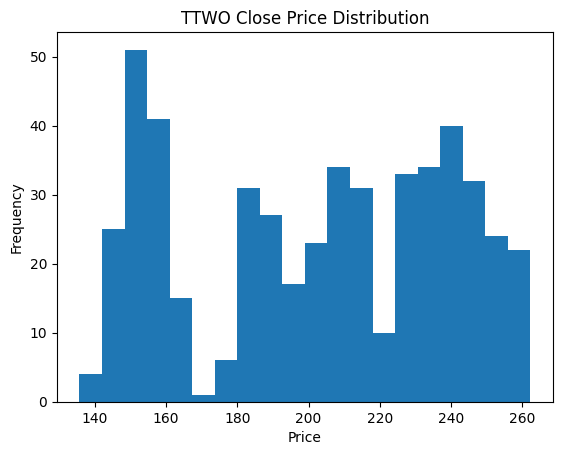

In [7]:
plt.figure()
plt.hist(df["Close"], bins=20)
plt.title("TTWO Close Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

TTWO shows a cluster of prices around the 150 dollar price, which indicates that the stock spent a meaningful amount of time trading in this lower range during the earlier part of the sample (2024). 

This suggests a sustained upward trend into higher trading prices, it highlights that the distribution is not centered around a single dominant price level instead it showcases multiple modes.

TTWO is negatively skewed towards 240 dollar price which aligns with the mean and median values. There is a cluster around this region (230-250) which indicates that the stock spent significant time trading at these values; 190-210 trading range is seen after the price drop of February.

Since the bulk of the price distribution is at the 230-250 it is likely that the drop to the 190-210 range was due to the change in market conditions rather than a sustained behavior.

## Lag Plot

The lag plot shows the relationship between each value and the previous one.

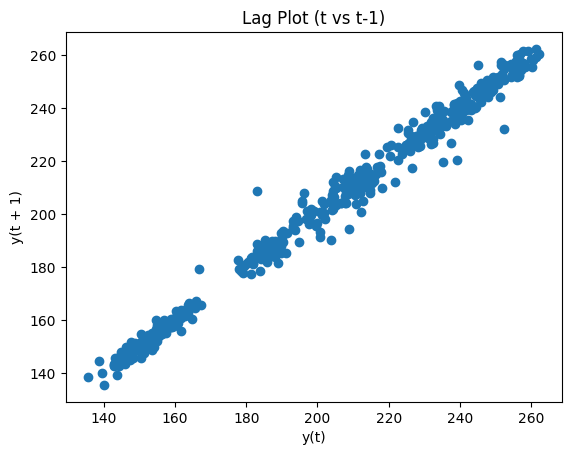

In [8]:
plt.figure()
lag_plot(df["Close"])
plt.title("Lag Plot (t vs t-1)")
plt.show()

Clearly there is a strong linear relationship between them, which translates to the yesterday values being very similar to today's values (e.g. if yesterday was high, today will also be high and vice-versa).

## Autocorrelation plot

The autocorrelation plot shows whether observations remain correlated across lags.

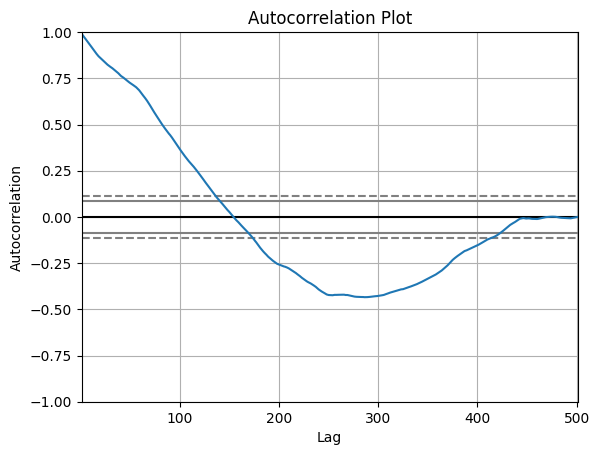

In [9]:
plt.figure()
autocorrelation_plot(df["Close"])
plt.title("Autocorrelation Plot")
plt.show()

By observing the plot, recent lags (lag = 1, 2, …, 10) show strong positive autocorrelation, while by around lag 150 the correlation coefficient is essentially null relative to the current time step. This means that the link between current and past values becomes weaker as the lag increases.

A very weak negative correlation appears around lag 250, suggesting that price movements more than half a year apart show a slight inverse relationship. However, this is clearly caused by the sharp price drop in February, which affects the autocorrelation pattern. Therefore, this observation does not provide any meaningful conclusion.

## Decomposition


### Classical decomposition

The classical decomposition method separates the series into trend, seasonal, and residual components; it assumes fixed, repeating seasonality. The trend is estimated using global moving averages. Seasonality needs to be known and constant, which in the case of TTWO is not so clear since most price moves are not based of a seasonal trend as seen during the last steps. 

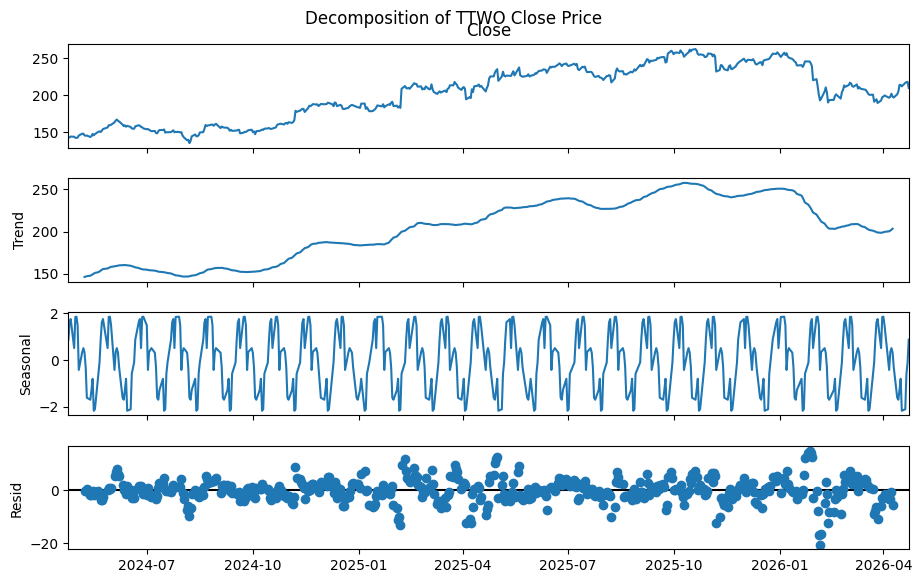

In [10]:
result = seasonal_decompose(df["Close"], model='additive', period=20)

fig = result.plot()
fig.set_size_inches(10, 6)
fig.suptitle("Decomposition of TTWO Close Price")

plt.show()

### STL decomposition

This cell uses STL decomposition to separate the series into trend, seasonal, and residual components. STL is more robust to outliers, works with seasonal periods and can change over time (improvement from the global moving averages). The trend and seasonality components are estimated using LOESS smoothing. 

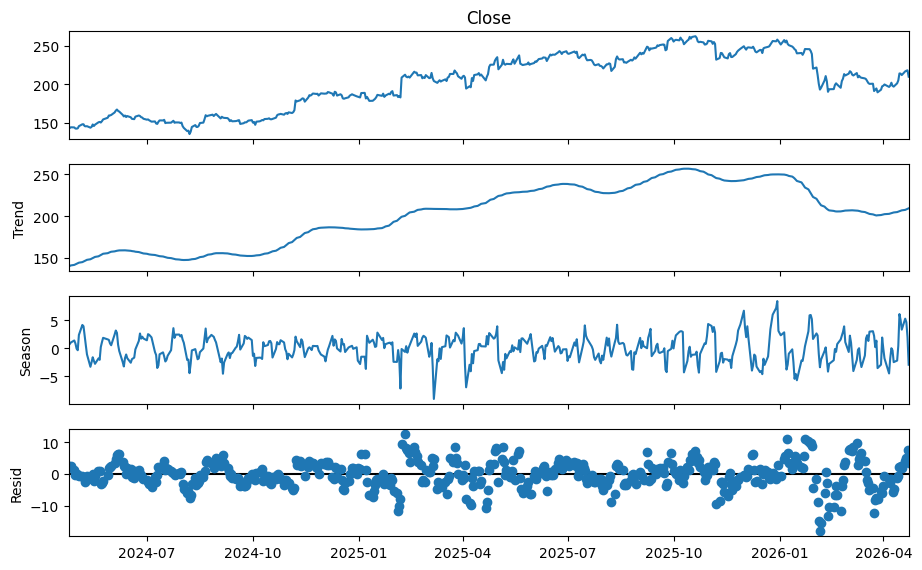

In [11]:
stl = STL(df["Close"], period=20)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(10, 6)
plt.show()

The reasoning behind choosing STL instead of the classical (seasonal_decompose) decomposition is due to the lack of periodic events in the TTWO price, which reflects a lack of seasonality. There are trends, volatility clusters, white noise, and price shocks; however, seasonality is hard to justify. Therefore, applying global moving averages to decompose the series would not be as precise as using local weighted regression, which is more flexible and resistant to noise.

Both plots are quite similar visually and logically; however, STL does show smoother trends. Looking at the residual plot, in the classical decomposition the residuals extend to around –20, meaning the model’s fitted value was about $20 higher than the actual price. Visually the graph seems smoother, but on the same scale there is clearly clustering around February during the price drop. On the contrary, the STL residual graph looks like white noise (with a similar nuance during February, but only around –10, meaning the fitted value was about $10 lower than the actual price), as it is supposed to.

Note that the "season" plot (third plot) illustrates that the patterns are not repeating or constant over the time axis, there are some local patterns occuring however they break after a while and do not repeat ever again, therefore there is no evidence of seasonality.

# Methodology

## Check for Stationary

The next two cells apply two standard stationarity tests:

- **ADF test**: null hypothesis is that the series is non-stationary
- **KPSS test**: null hypothesis is that the series is stationary

### ADF test

In [12]:
adf_result = adfuller(df["Close"])

print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic: -1.7282492962230125
p-value: 0.4166194928105515
1%: -3.443496379464
5%: -2.8673378563200003
10%: -2.569858036
Series is non-stationary


ADF hypothesis test tells us that the series is not stationary. The test result did not provide enough evidence to reject the null hypothesis. In other words, the series behaves like a random walk, with changing mean and variance over time.

### KPSS test

In [13]:
kpss_result = kpss(df["Close"], regression="c", nlags="auto")

print(f"KPSS Statistic: {kpss_result[0]}")
print(f"p-value: {kpss_result[1]}")
print(f"Lags used: {kpss_result[2]}")

for key, value in kpss_result[3].items():
    print(f"{key}: {value}")

if kpss_result[1] < 0.05:
    print("Series is non-stationary")
else:
    print("Series is stationary")


KPSS Statistic: 3.0325634270104516
p-value: 0.01
Lags used: 12
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739
Series is non-stationary


The KPSS test rejects the null hypothesis of stationarity (stat = 3.03, p = 0.01).

The series is non‑stationary.

Both the ADF and KPSS outcomes are consistent with the visual inspection, which already indicated non‑stationarity due to shifting mean values and changes in the spread of values.

## Differencing, log

Simplest method to detrend a time series is by differencing. Let's create reusable differencing and log variables of the ``Close`` series.

In [14]:
df["Log_Close"] = np.log(df["Close"])
df["Diff_Close"] = df["Close"].diff()
df["Diff_Log_Close"] = df["Log_Close"].diff()

df[["Close", "Log_Close", "Diff_Close", "Diff_Log_Close"]].head()

transformed_series = df["Diff_Log_Close"].dropna()

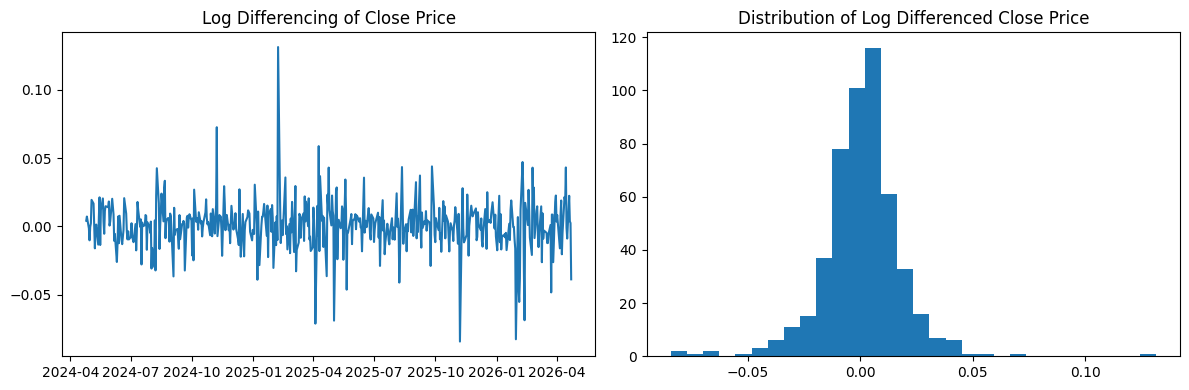

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Line plot
axes[0].plot(df["Diff_Log_Close"])
axes[0].set_title("Log Differencing of Close Price")

# Histogram
axes[1].hist(df["Diff_Log_Close"], bins=30)
axes[1].set_title("Distribution of Log Differenced Close Price")

plt.tight_layout()
plt.show()


By observing the graph, the mean of the differenced series is close to 0. There is no clear upward or downward trend, and it looks like white noise (normally distributed, based on the histogram). The variance also looks constant, meaning the trend component has been removed by performing log‑differencing.

Now the series is closer to stationary.

In [16]:
adf_result = adfuller(df["Diff_Log_Close"].dropna())

print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic: -22.10317236867178
p-value: 0.0
1%: -3.4435228622952065
5%: -2.867349510566146
10%: -2.569864247011056
Series is stationary


## Model Selection

### ACF and PACF of the transformed series

Definition:
- **ACF**: Measures the correlation between a time series and its own lagged values, helping to identify overall trends and seasonality in the data. This includes all lag effects mixed together. For example, ACF at lag k includes indirect effects because the data has dependency chains (so lag 2, lag 3, ... till k). This enables calculation via indirect effects (lag 2 -> current; lag 2 -> lag 1; lag 2 -> lag 1 -> current, etc...)

- **PACF**: Measures the partial correlation of a stationary time series with its own lagged values, controlling for the values of the time series at all shorter lags. This includes the specific lag effect k. For example, it calculates the autocorrelation coeficient of lag k without the in between values. This enables calculation of **only** direct effects (lag 2 -> current)

**ACF** helps determine the **(MA)** structure while **PACF** helps determine the **(AR)** structure.

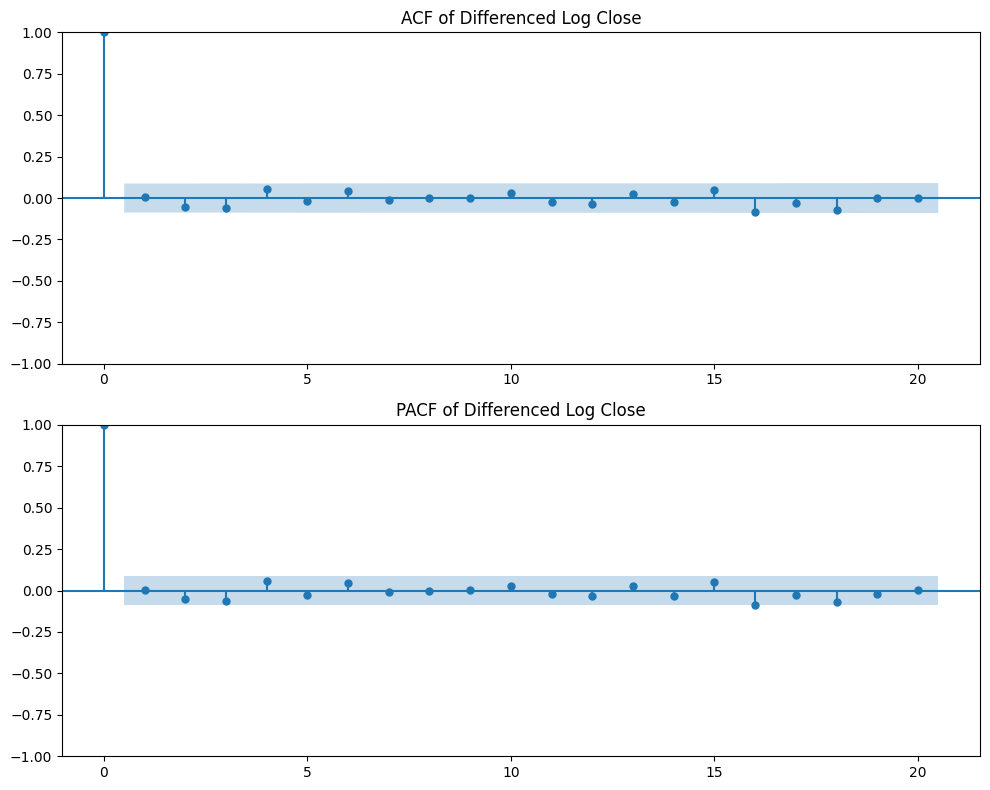

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(transformed_series, lags=20, ax=axes[0])
axes[0].set_title("ACF of Differenced Log Close")

plot_pacf(transformed_series, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Differenced Log Close")

plt.tight_layout()
plt.show()

The ACF and PACF of the log-differenced series show a single significant spike at lag 1, with all other lags inside the confidence bands.

In general, when there are no spikes it suggests that the differenced series is composed of white noise, which is typical of efficient markets. 

This indicates that only short term dependence remains, this tells us:
- **AR(1)** or **MA(1)** structure

Which supports using a simple ARIMA model such as:
- **ARIMA(1,1,0)**, 
- **ARIMA(0,1,1)**,
- **ARIMA(1,1,1)**.

### Train-test split

The last 30 trading days are used as the test set. This keeps the evaluation simple and gives a clear forecast accuracy section.

In [18]:
test_size = 30

train = df.iloc[:-test_size].copy()
test = df.iloc[-test_size:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min().date(), "to", train.index.max().date())
print("Testing period:", test.index.min().date(), "to", test.index.max().date())

Training observations: 471
Testing observations: 30
Training period: 2024-04-24 to 2026-03-11
Testing period: 2026-03-12 to 2026-04-23


### Naïve Baseline - Random Walk

Before fitting ARIMA, a persistence model is used as a simple baseline. This predicts that the next close price will be the same as the previous one. Following the high correlation value from the previous lag relative to the current lag. Knowing that there is high autocorrelation from lag 1, this baseline model is appropriate.

Note that the naïve model is mathematically equivalent to an ARIMA(0,1,0) process and serves as the standard benchmark for financial time series.

In [19]:
baseline_forecast = test["Close"].shift(1)
baseline_forecast.iloc[0] = train["Close"].iloc[-1]

baseline_rmse = np.sqrt(np.mean((test["Close"] - baseline_forecast) ** 2))
baseline_mae = np.mean(np.abs(test["Close"] - baseline_forecast))

print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline MAE: {baseline_mae:.4f}")

Baseline RMSE: 3.7850
Baseline MAE: 2.8670


### ARIMA

ARIMA (Auto Regressive Integrated Moving Average) is the preffered model over something like SARIMA because in this data there is no seasonality component. After log differencing there is no clear trend and variance is roughly constant, after performing ADF test on the differenced series it is clear that the series can be considered stationary.


In [20]:
candidate_orders = [(1,1,0), (0,1,1), (1,1,1)]
results = []

for order in candidate_orders:
    model = ARIMA(train["Close"], order=order).fit()
    results.append({
        "order": order,
        "AIC": model.aic,
        "BIC": model.bic
    })

print(pd.DataFrame(results).sort_values("AIC"))

       order          AIC          BIC
1  (0, 1, 1)  2586.941349  2595.246815
0  (1, 1, 0)  2586.941721  2595.247186
2  (1, 1, 1)  2587.985775  2600.443973


From the three candidate models, the model ARIMA(0,1,1) has lowest AIC and BIC values, while ARIMA(1,1,0) producing nearly identical results. ARIMA(1,1,1) performed worse due to the additional parameter.

Considering the results from AIC and BIC alone ARIMA(0,1,1) would be the wisest choice. These results were to be expected since their ACF and PACF plots were very similar to beggin with.

In broader financial terms, even though past values are relevant (where AR(1) is more prevalent), stocks and markets react to unexpected news not only past values, earnings surprises, geopolitical tensions and events, macro market announcements (such as monetary policy), etc... therefore MA(1) is a more prevalent model considering this prior knowledge.

#### ARIMA grid search

In [21]:
grid_results = []

for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 4):
            try:
                model = ARIMA(train["Close"], order=(p, d, q))
                fitted_model = model.fit()
                grid_results.append({"order": (p, d, q), "AIC": fitted_model.aic, "BIC": fitted_model.bic})
            except Exception:
                continue

In [22]:
grid_results = pd.DataFrame(grid_results).sort_values("AIC").reset_index(drop=True)
print(grid_results.head(10))

       order          AIC          BIC
0  (2, 1, 3)  2581.569735  2606.486131
1  (0, 1, 0)  2584.944005  2589.096737
2  (1, 1, 3)  2585.108714  2605.872377
3  (3, 1, 1)  2585.177399  2605.941063
4  (3, 1, 0)  2586.123623  2602.734554
5  (0, 1, 3)  2586.401601  2603.012532
6  (2, 1, 0)  2586.666197  2599.124395
7  (3, 1, 2)  2586.757229  2611.673625
8  (0, 1, 2)  2586.904439  2599.362638
9  (0, 1, 1)  2586.941349  2595.246815


In terms of AIC, ARIMA(0,1,1) actually performs the worst compared the other candidate models. However their AIC values are very close nonetheless, ARIMA(2,1,3) has too many parameters so its likely to overfit the data, hence it would probably not be a good choice.

In [23]:
grid_results = pd.DataFrame(grid_results).sort_values("BIC").reset_index(drop=True)
print(grid_results.head(10))

       order          AIC          BIC
0  (0, 1, 0)  2584.944005  2589.096737
1  (0, 1, 1)  2586.941349  2595.246815
2  (1, 1, 0)  2586.941721  2595.247186
3  (2, 1, 0)  2586.666197  2599.124395
4  (0, 1, 2)  2586.904439  2599.362638
5  (1, 1, 1)  2587.985775  2600.443973
6  (3, 1, 0)  2586.123623  2602.734554
7  (0, 1, 3)  2586.401601  2603.012532
8  (2, 1, 1)  2587.789077  2604.400008
9  (1, 1, 2)  2588.168087  2604.779018


Examining the best models based on the BIC, ARIMA(0,1,1) performs the best after the base model. 

#### Final model selection

Based on the AIC and BIC values, ARIMA(0,1,1) the model aside from the baseline with less parameters has the lowest BIC, then on the contrary it sits as the highest AIC of the group, in model evaluation, flexibility is a very important consideration since prediction is the final goal of modeling series... the model that would do best is the model which is less prone to overfit while still doing a good job at generally predicting values, which is the less flexible model.

Recalling that BIC penalizes model complexity and that AIC does not penalize overfitting sufficiently, ARIMA(0,1,1) is arguably the best model over the rest of the candidates. Since the final goal is out-of-sample prediction, BIC is the more appropriate criterion here, making the higher AIC of ARIMA(0,1,1) a secondary concern. In this case, ARIMA(0,1,1) having less parameters means it has less flexibility and is less prone to overfit while capturing the underlying structure of the data.

No model simultaneously minimises both AIC and BIC, so committing to one criterion based on the modeling objective is necessary. From those models they all perform worse on AIC and BIC compared to the baseline, therefore ARIMA(0,1,1) has the best statistics out of the group.

Why not choose just the base model? The base model although it scores relatively well compared to the other models, is not entirely suitable since it is merely capturing the fact that the previous lag prices are highly correlated with the current prices, this is already known from the ACF and PACF plots, the model does not bring any new information or prediction value beyond a naive lag structure, compared to the other models that at least deviate from that known fact.

Final Selection: **ARIMA(0,1,1)**

In [24]:
final_model = ARIMA(df["Close"], order=(0, 1, 1)).fit()
print(final_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  501
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1373.972
Date:                Sun, 26 Apr 2026   AIC                           2751.943
Time:                        21:07:58   BIC                           2760.373
Sample:                             0   HQIC                          2755.251
                                - 501                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0012      0.043     -0.027      0.978      -0.085       0.082
sigma2        14.2674      0.406     35.174      0.000      13.472      15.062
Ljung-Box (L1) (Q):                   0.00   Jarque-

# Diagnostics

After fitting ARIMA(0,1,1), the diagnostics section will be used to analyze residuals. A well designed model should make residuals behave like white noise, uncorrelated, centred at 0 and normally distributed. 

## Residuals over time & distribution

The residuals are plotted over time to check for any remaining patterns or clustering. If the model is well specified, residuals should fluctuate randomly around zero with no visible structure.

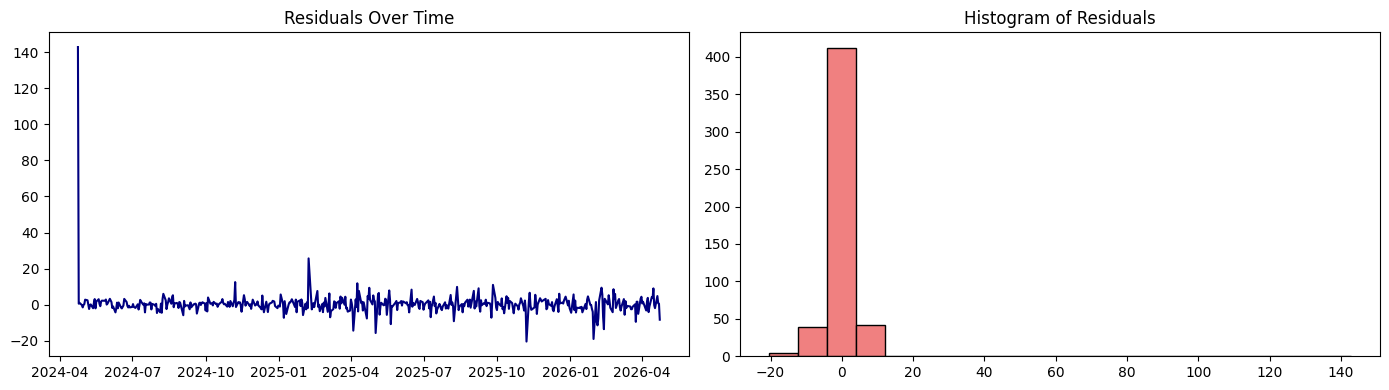

In [25]:
residuals = pd.Series(final_model.resid).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals, color="navy")
axes[0].set_title("Residuals Over Time")

axes[1].hist(residuals, bins=20, color="lightcoral", edgecolor="black")
axes[1].set_title("Histogram of Residuals")

plt.tight_layout()
plt.show()

The residuals for the majority of the series are centred at zero, which is consistent with white noise behaviour. The large spike at the first residual is due to the fact that the initial prediction is based solely on the intercept — once the MA(1) correction kicks in from the second observation onward, the residuals centre around zero with no systematic drift or pattern.

In [26]:
residuals = residuals.iloc[1:]  # drop the first residual

## QQ-plot

The Q-Q plot compares the distribution of residuals against a theoretical normal distribution. Points that follow the diagonal line indicate normality.

<Figure size 640x480 with 0 Axes>

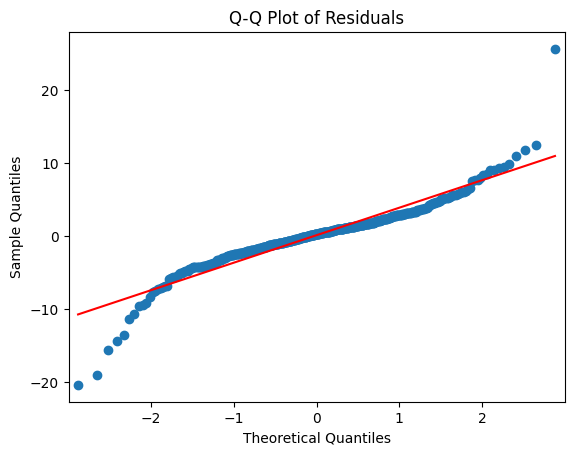

In [27]:
plt.figure()
qqplot(residuals, line="s")
plt.title("Q-Q Plot of Residuals")
plt.show()

The residuals approximate normality (with the first value exception discussed).

There are deviations at both tails which tells that the distribution has heavy tails making a mild "S" shape. It means that extreme price movements occur more frequently than a normal distribution would predict, which is expected behaviour in financial time series since prices are traded by headline news which might spike the price unexpectedly.

## ACF of the residuals

The ACF of the residuals checks for any remaining autocorrelation that the model failed to capture. Ideally all lags should fall within the 95% confidence bands, confirming the residuals are uncorrelated.

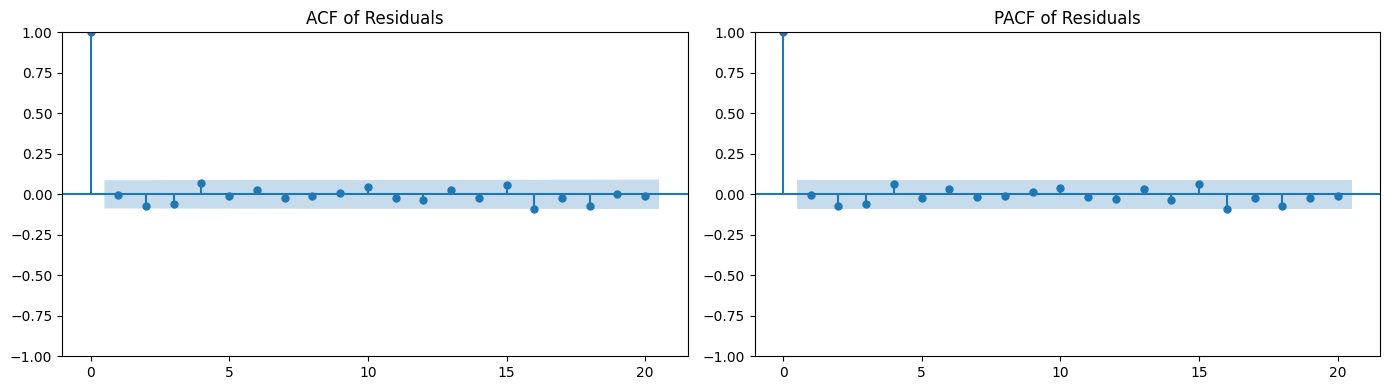

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(residuals, lags=20, ax=axes[0])
axes[0].set_title("ACF of Residuals")

plot_pacf(residuals, lags=20, ax=axes[1])
axes[1].set_title("PACF of Residuals")

plt.tight_layout()
plt.show()

Similar to what was observed before modeling.

## Ljung-box

The Ljung-Box test tests whether the residuals are independently distributed up to lag 10.

The null hypothesis is that there is no autocorrelation in the residuals.

A p-value above 0.05 means we fail to reject the null, which is the desired outcome and confirms the model has captured the dependence structure of the series.

In [29]:
ljung_box_results = acorr_ljungbox(residuals, lags=[10], return_df=True)
ljung_box_results

,lb_stat,lb_pvalue
10,8.807743,0.550442


0.468356 > 0.05 -> fail to reject null-hypothesis, no autocorrelation in the residuals.

ARIMA(0,1,1) has successfully captured the dependence structure of the series and the residuals behave as white noise.

# Forecasting

With the model validated through diagnostics, forecasting is performed in two stages:
- Forecasting against the test data.
- Future Forecasting 


First, the model trained on the training set is evaluated against the test data to quantify predictive accuracy.

Second, the model is refitted on the full dataset and used to generate a genuine 10-step ahead forecast into the future.

## Plot Forecasting

The model trained on the training set generates forecasts over the 30-day test period.

The forecast is compared against the actual observed close prices, along with a 95% confidence interval which reflects the uncertainty of each prediction.

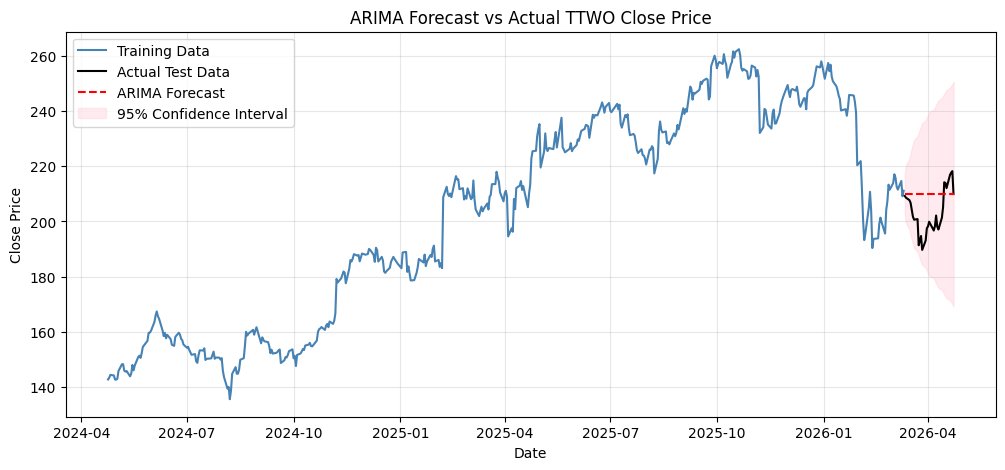

In [30]:
test_forecast_result = final_model.get_forecast(steps=len(test))
test_forecast = pd.Series(test_forecast_result.predicted_mean.values, index=test.index)
test_ci = test_forecast_result.conf_int()
test_ci.index = test.index

plt.figure(figsize=(12, 5))
plt.plot(train.index, train["Close"], label="Training Data", color="steelblue")
plt.plot(test.index, test["Close"], label="Actual Test Data", color="black")
plt.plot(test.index, test_forecast, label="ARIMA Forecast", color="red", linestyle="--")
plt.fill_between(test.index, test_ci.iloc[:, 0], test_ci.iloc[:, 1], color="pink", alpha=0.3, label="95% Confidence Interval")
plt.title("ARIMA Forecast vs Actual TTWO Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The ARIMA(0,1,1) forecast over the test period produces a flat forecast around $210. Since ARIMA(0,1,1) has no autoregressive terms, the forecast converges to a constant after the first step.

The actual test data however shows continued volatility, dipping to around $190 before recovering above $210.

The 95% confidence interval is wide and does contain the actual values for most of the test period, meaning the model is not wrong, but it is not tracking the short term movements either.

This is expected behaviour for a financial series where price changes are largely unpredictable beyond the immediate next step. In a efficient market (e.g. without insider information) scenario, stock prices are modeled as stochastic processes which incorporate a random component that cannot be deterministically predicted.

## MAPE helper function

MAPE (Mean Absolute Percentage Error) expresses forecast error as a percentage of the actual values, making it easier to interpret in relative terms regardless of the price scales.

In [31]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

## Error metrics and comparison table
 
Lower values indicate better predictive accuracy. 

The baseline is a strong benchmark for financial series due to the high lag-1 autocorrelation observed earlier, so any improvement, is meaningful even if modest.

In [32]:
arima_rmse = np.sqrt(np.mean((test["Close"] - test_forecast) ** 2))
arima_mae = np.mean(np.abs(test["Close"] - test_forecast))
arima_mape = mean_absolute_percentage_error(test["Close"], test_forecast)

accuracy_table = pd.DataFrame({
    "Model": ["Baseline", "ARIMA(0,1,1)"],
    "RMSE": [baseline_rmse, arima_rmse],
    "MAE": [baseline_mae, arima_mae],
    "MAPE": [mean_absolute_percentage_error(test["Close"], baseline_forecast), arima_mape],
})

print(accuracy_table)

          Model       RMSE       MAE      MAPE
0      Baseline   3.785035  2.866999  1.418605
1  ARIMA(0,1,1)  10.350241  8.848155  4.443202


Unsurprisingly, the baseline outperforms ARIMA(0,1,1) which is a consequence of the baseline updating its prediction based on the actual last observed price, giving it very high accuracy.

However in a longer term context the model would probably not fit very well since its accuracy depends mostly of the most recent lag.

## Forecast the future

After validating the ARIMA(0,1,1) model with the train and test sets, a 10-step forcast will be generated (10 business days beyond the last observed date). 

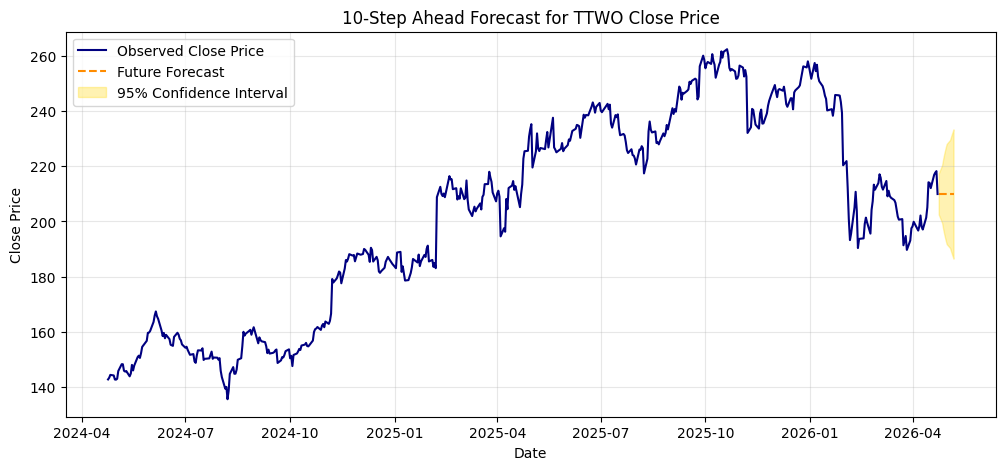

In [33]:
forecast_future_lag = 10
future_index = pd.bdate_range(start=df.index[-1] + pd.offsets.BDay(1), periods=forecast_future_lag)

future_forecast_result = final_model.get_forecast(steps=forecast_future_lag)
future_forecast = pd.Series(future_forecast_result.predicted_mean.values, index=future_index)
future_ci = future_forecast_result.conf_int()
future_ci.index = future_index

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"], label="Observed Close Price", color="navy")
plt.plot(future_index, future_forecast, label="Future Forecast", color="darkorange", linestyle="--")
plt.fill_between(future_index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color="gold", alpha=0.3, label="95% Confidence Interval")
plt.title("10-Step Ahead Forecast for TTWO Close Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The widening confidence interval reflects the compounding uncertainty of multi-step forecasting, which is a representation of the limits of stock price prediction.

# Conclusion

This project analysed and forecasted the closing price of Take-Two Interactive (TTWO) stock over a two-year period from April 2024 to April 2026.

The exploratory data analysis confirmed that the series is non-stationary, from which it clearly shows an upward trend throughout 2025, then followed by a sharp price drop in February 2026. 

The ADF and KPSS tests corroborated the fact that the series is non-stationary.

Log-differencing was applied to achieve stationarity, producing a series that resembles white noise with roughly constant variance.

The ACF and PACF of the differenced series indicated short-term dependence at lag 1 only, which motivates the use of simple ARIMA models. 


Following a grid search evaluated by AIC and BIC, ARIMA(0,1,1) was selected as the final model; while ARIMA(0,1,1) did not achieve the lowest AIC score it, stood out as the lowest BIC score following the baseline which is important since the objective is forecasting the future out of the known sample data, hence choosing a model that is less complicated while generalizing well (without overfit) is ideal. 

The MA(1) structure from ARIMA(0,1,1) is consistent with prior financial knowledge where prices react to unexpected events, such as news or earnings reports, rather than following a pure autoregressive process. 

During the diagnostics section it was confirmed that the model generalized well, with the residuals resembling white noise (random scatter) while being approximately normally distributed. The Ljung-Box test corroborates this affirmation too.

In terms of accuracy regarding forecasting, while performing on the test set, ARIMA(0,1,1) was compared with the baseline model ARIMA(0,1,0), which the baseline outperformed ARIMA(0,1,1) since the baseline directly depends on previous lag it achieves very high accuracy comparatively, however in a long term period it is likely it would not perform very well considering how stocks react whenever there are market events. 

Finally, a 10-step ahead forecast was generated using the full dataset, providing a constant flat forecast (since ARIMA(0,1,1) does not have the autoregressive parameter) bounded by the 95% confidence interval where the price is most likely going to be trading at the next 10 days.

## Future Work

Future work regarding this project and evaluating this series would involve exploring other modeling alternatives, such as machine learning models: 
- Regression models
- FNN
- CNN
- LSTM
Followed by comparing their performances with the chosen model ARIMA(0,1,1).

Additionally, alternative statistical models such as Prophet from the prophet library were not explored. 

## Limitations

Data limitations for instance, this report only looked at the past 2 years, seasonal trends may be present if a longer time period is considered.

Only one series was evaluated, hence the model would most likely not generalize well versus other stocks. 

ARIMA assumes linearity, sudden drops in price such as the February 2026 drop would make a linear model not grasp its structure.

Flat forecast since ARIMA(0,1,1) lacks the AR(1) structure, which limits its usefulness over longer time horizons.

Only one variable was modeled (Close price), external variables such as the trading volume, market index movements, sentiment analysis, etc. would complement the model.